In [7]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv('data/case1Data.csv')
X_test = pd.read_csv('data/case1Data_Xnew.csv')

In [9]:
y = data['y']
X = data.drop('y', axis=1)

#categorical features
cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]


for c in cat_cols:
    X[c] = X[c].astype("string")
    X[c] = X[c].fillna("Missing")
    X[c] = X[c].astype("category")       

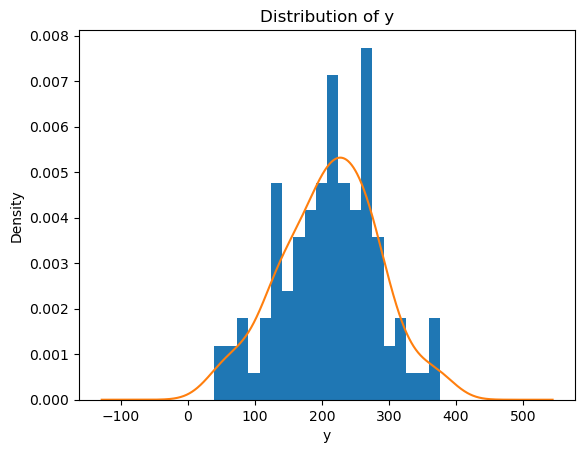

In [10]:

plt.figure()
pd.Series(y).plot(kind="hist", bins=20, density=True)
pd.Series(y).plot(kind="kde")
plt.xlabel("y")
plt.title("Distribution of y")
plt.show()

In [11]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in kf.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        tree_method="hist",
        enable_categorical=True
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    rmse = np.sqrt(((pred - y_val)**2).mean())
    scores.append(rmse)

print("CV RMSE:", np.mean(scores))


CV RMSE: 51.828445889812954


In [12]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


X_num = X.drop(columns=cat_cols)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_num = pd.DataFrame(
    imputer.fit_transform(X_num),
    columns=X_num.columns
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.2,0.5,0.8,0.9,1.0],
        cv=5,
        max_iter=10000
    ))
])

pipe.fit(X_num, y)

elastic = pipe.named_steps["elastic"]

selected = np.abs(elastic.coef_) > 1e-6
selected_features = X_num.columns[selected]

print("Selected features:", len(selected_features))

Selected features: 65


In [14]:
print(elastic.alpha_)
print(elastic.l1_ratio_)

0.34844453085513627
1.0


In [19]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

selected_num_features = [c for c in selected_features if c not in cat_cols]
use_cols = selected_num_features + cat_cols

X_model = X[use_cols].copy()
X_test_model = X_test[use_cols].copy()

# categorical handling
for c in cat_cols:
    X_model[c] = X_model[c].astype("string").fillna("Missing").astype("category")
    X_test_model[c] = X_test_model[c].astype("string").fillna("Missing").astype("category")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X_model))
test_preds = np.zeros(len(X_test_model))
fold_rmses = []
best_iters = []

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42,
}

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_model), 1):
    X_tr, X_va = X_model.iloc[tr_idx], X_model.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtr = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dva = xgb.DMatrix(X_va, label=y_va, enable_categorical=True)
    dte = xgb.DMatrix(X_test_model, enable_categorical=True)

    booster = xgb.train(
        params,
        dtr,
        num_boost_round=5000,
        evals=[(dva, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_va = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
    oof[va_idx] = pred_va

    rmse = np.sqrt(mean_squared_error(y_va, pred_va))
    fold_rmses.append(rmse)
    best_iters.append(booster.best_iteration)

    test_preds += booster.predict(
        dte, iteration_range=(0, booster.best_iteration + 1)
    ) / kf.n_splits

print("Fold RMSEs:", fold_rmses)
print("OOF RMSE  :", np.sqrt(mean_squared_error(y, oof)))
print("Fold RMSE std:", np.std(fold_rmses))
print("Best iters:", best_iters, "median:", int(np.median(best_iters)))

Fold RMSEs: [np.float64(51.06344995482697), np.float64(39.438494301745386), np.float64(27.837043819176664), np.float64(54.131199753684484), np.float64(51.41106279739456)]
OOF RMSE  : 45.849876613573606
Fold RMSE std: 9.86400578824953
Best iters: [1730, 1425, 4993, 1035, 744] median: 1425


In [25]:
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

alphas = []
l1_ratios = []

# -----------------------------
# Feature sets
# -----------------------------
selected_num_features = [c for c in selected_features if c not in cat_cols]
reduced_cols = selected_num_features + cat_cols
full_cols = X.columns.tolist()

X_reduced = X[reduced_cols].copy()
X_full = X[full_cols].copy()

# -----------------------------
# categorical handling for XGBoost
# -----------------------------
for c in cat_cols:
    if c in X_reduced.columns:
        X_reduced[c] = X_reduced[c].astype("string").fillna("Missing").astype("category")

    if c in X_full.columns:
        X_full[c] = X_full[c].astype("string").fillna("Missing").astype("category")

# -----------------------------
# ElasticNet dataset
# one-hot encoding
# -----------------------------
X_en = pd.get_dummies(X, dummy_na=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42,
}

# storage
oof_reduced = np.zeros(len(X))
oof_full = np.zeros(len(X))
oof_en = np.zeros(len(X))

fold_rmses_reduced = []
fold_rmses_full = []
fold_rmses_en = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):

    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # =====================
    # Reduced XGBoost
    # =====================
    X_tr_red, X_va_red = X_reduced.iloc[tr_idx], X_reduced.iloc[va_idx]

    dtr_red = xgb.DMatrix(X_tr_red, label=y_tr, enable_categorical=True)
    dva_red = xgb.DMatrix(X_va_red, label=y_va, enable_categorical=True)

    booster_red = xgb.train(
        params,
        dtr_red,
        num_boost_round=5000,
        evals=[(dva_red, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_red = booster_red.predict(
        dva_red, iteration_range=(0, booster_red.best_iteration + 1)
    )

    oof_reduced[va_idx] = pred_red
    rmse_red = np.sqrt(mean_squared_error(y_va, pred_red))
    fold_rmses_reduced.append(rmse_red)

    # =====================
    # Full XGBoost
    # =====================
    X_tr_full, X_va_full = X_full.iloc[tr_idx], X_full.iloc[va_idx]

    dtr_full = xgb.DMatrix(X_tr_full, label=y_tr, enable_categorical=True)
    dva_full = xgb.DMatrix(X_va_full, label=y_va, enable_categorical=True)

    booster_full = xgb.train(
        params,
        dtr_full,
        num_boost_round=5000,
        evals=[(dva_full, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_full = booster_full.predict(
        dva_full, iteration_range=(0, booster_full.best_iteration + 1)
    )

    oof_full[va_idx] = pred_full
    rmse_full = np.sqrt(mean_squared_error(y_va, pred_full))
    fold_rmses_full.append(rmse_full)

    # =====================
    # ElasticNet
    # =====================
    X_tr_en, X_va_en = X_en.iloc[tr_idx], X_en.iloc[va_idx]

    model_en = Pipeline([
        ("scaler", StandardScaler()),
        ("elastic", ElasticNetCV(
            l1_ratio=[0.2,0.5,0.8,0.9,1.0],
            cv=5,
            max_iter=10000
        ))
    ])

    model_en.fit(X_tr_en, y_tr)
    alphas.append(model_en.named_steps["elastic"].alpha_)
    l1_ratios.append(model_en.named_steps["elastic"].l1_ratio_)
    pred_en = model_en.predict(X_va_en)

    oof_en[va_idx] = pred_en
    rmse_en = np.sqrt(mean_squared_error(y_va, pred_en))
    fold_rmses_en.append(rmse_en)

    print(
        f"Fold {fold}: "
        f"reduced={rmse_red:.2f}, "
        f"full={rmse_full:.2f}, "
        f"elastic={rmse_en:.2f}"
    )

# -----------------------------
# Results
# -----------------------------
print("\n--- REDUCED XGBOOST ---")
print("OOF RMSE:", np.sqrt(mean_squared_error(y, oof_reduced)))

print("\n--- FULL XGBOOST ---")
print("OOF RMSE:", np.sqrt(mean_squared_error(y, oof_full)))

print("\n--- ELASTIC NET ---")
print("OOF RMSE:", np.sqrt(mean_squared_error(y, oof_en)))

print("\nElasticNet alphas:", alphas)
print("ElasticNet l1_ratios:", l1_ratios)

ValueError: Input X contains NaN.
ElasticNetCV does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [26]:
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

alphas = []
l1_ratios = []
# -----------------------------
# Feature sets
# -----------------------------
selected_num_features = [c for c in selected_features if c not in cat_cols]
reduced_cols = selected_num_features + cat_cols
full_cols = X.columns.tolist()

X_reduced = X[reduced_cols].copy()
X_full = X[full_cols].copy()

# -----------------------------
# categorical handling for XGBoost
# -----------------------------
for c in cat_cols:
    if c in X_reduced.columns:
        X_reduced[c] = X_reduced[c].astype("string").fillna("Missing").astype("category")

    if c in X_full.columns:
        X_full[c] = X_full[c].astype("string").fillna("Missing").astype("category")

# -----------------------------
# ElasticNet dataset
# Use reduced feature set for fairer comparison
# one-hot encode categoricals
# -----------------------------
X_en = X[reduced_cols].copy()

for c in cat_cols:
    if c in X_en.columns:
        X_en[c] = X_en[c].astype("string").fillna("Missing")

X_en = pd.get_dummies(X_en, dummy_na=True).astype(float)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42,
}

# storage
oof_reduced = np.zeros(len(X))
oof_full = np.zeros(len(X))
oof_en = np.zeros(len(X))

fold_rmses_reduced = []
fold_rmses_full = []
fold_rmses_en = []

best_iters_reduced = []
best_iters_full = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):

    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # =====================
    # Reduced XGBoost
    # =====================
    X_tr_red, X_va_red = X_reduced.iloc[tr_idx], X_reduced.iloc[va_idx]

    dtr_red = xgb.DMatrix(X_tr_red, label=y_tr, enable_categorical=True)
    dva_red = xgb.DMatrix(X_va_red, label=y_va, enable_categorical=True)

    booster_red = xgb.train(
        params,
        dtr_red,
        num_boost_round=5000,
        evals=[(dva_red, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_red = booster_red.predict(
        dva_red, iteration_range=(0, booster_red.best_iteration + 1)
    )

    oof_reduced[va_idx] = pred_red
    rmse_red = np.sqrt(mean_squared_error(y_va, pred_red))
    fold_rmses_reduced.append(rmse_red)
    best_iters_reduced.append(booster_red.best_iteration)

    # =====================
    # Full XGBoost
    # =====================
    X_tr_full, X_va_full = X_full.iloc[tr_idx], X_full.iloc[va_idx]

    dtr_full = xgb.DMatrix(X_tr_full, label=y_tr, enable_categorical=True)
    dva_full = xgb.DMatrix(X_va_full, label=y_va, enable_categorical=True)

    booster_full = xgb.train(
        params,
        dtr_full,
        num_boost_round=5000,
        evals=[(dva_full, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_full = booster_full.predict(
        dva_full, iteration_range=(0, booster_full.best_iteration + 1)
    )

    oof_full[va_idx] = pred_full
    rmse_full = np.sqrt(mean_squared_error(y_va, pred_full))
    fold_rmses_full.append(rmse_full)
    best_iters_full.append(booster_full.best_iteration)

    # =====================
    # ElasticNet
    # =====================
    X_tr_en, X_va_en = X_en.iloc[tr_idx], X_en.iloc[va_idx]

    model_en = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("elastic", ElasticNetCV(
            l1_ratio=[0.2, 0.5, 0.8, 0.9, 1.0],
            cv=5,
            max_iter=10000
        ))
    ])

    model_en.fit(X_tr_en, y_tr)
    
    alphas.append(model_en.named_steps["elastic"].alpha_)
    l1_ratios.append(model_en.named_steps["elastic"].l1_ratio_)
    pred_en = model_en.predict(X_va_en)

    oof_en[va_idx] = pred_en
    rmse_en = np.sqrt(mean_squared_error(y_va, pred_en))
    fold_rmses_en.append(rmse_en)

    print(
        f"Fold {fold}: "
        f"reduced={rmse_red:.2f}, "
        f"full={rmse_full:.2f}, "
        f"elastic={rmse_en:.2f}"
    )

# -----------------------------
# Results
# -----------------------------
rmse_reduced = np.sqrt(mean_squared_error(y, oof_reduced))
rmse_full = np.sqrt(mean_squared_error(y, oof_full))
rmse_en = np.sqrt(mean_squared_error(y, oof_en))

print("\n--- REDUCED XGBOOST ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_reduced])
print("OOF RMSE:", rmse_reduced)
print("Fold RMSE std:", np.std(fold_rmses_reduced))
print("Best iters:", best_iters_reduced, "median:", int(np.median(best_iters_reduced)))

print("\n--- FULL XGBOOST ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_full])
print("OOF RMSE:", rmse_full)
print("Fold RMSE std:", np.std(fold_rmses_full))
print("Best iters:", best_iters_full, "median:", int(np.median(best_iters_full)))

print("\n--- ELASTIC NET ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_en])
print("OOF RMSE:", rmse_en)
print("Fold RMSE std:", np.std(fold_rmses_en))

# -----------------------------
# Optional simple ensemble
# -----------------------------
oof_ensemble = 0.5 * oof_reduced + 0.5 * oof_en
rmse_ensemble = np.sqrt(mean_squared_error(y, oof_ensemble))

print("\n--- 50/50 ENSEMBLE: REDUCED XGBOOST + ELASTIC NET ---")
print("OOF RMSE:", rmse_ensemble)

print("\nElasticNet alphas:", alphas)
print("ElasticNet l1_ratios:", l1_ratios)

Fold 1: reduced=51.06, full=56.57, elastic=35.39
Fold 2: reduced=39.44, full=38.95, elastic=24.81
Fold 3: reduced=27.84, full=31.10, elastic=32.03
Fold 4: reduced=54.13, full=56.10, elastic=32.46
Fold 5: reduced=51.41, full=53.04, elastic=39.11

--- REDUCED XGBOOST ---
Fold RMSEs: [51.06344995482697, 39.438494301745386, 27.837043819176664, 54.131199753684484, 51.41106279739456]
OOF RMSE: 45.849876613573606
Fold RMSE std: 9.86400578824953
Best iters: [1730, 1425, 4993, 1035, 744] median: 1425

--- FULL XGBOOST ---
Fold RMSEs: [56.574824331592794, 38.94501579311416, 31.097932487054273, 56.09686990777628, 53.03510139405069]
OOF RMSE: 48.257822581573436
Fold RMSE std: 10.281039349293547
Best iters: [648, 755, 4985, 804, 537] median: 755

--- ELASTIC NET ---
Fold RMSEs: [35.38642778796367, 24.807226396475016, 32.029050143572334, 32.45570748905691, 39.10816600087523]
OOF RMSE: 33.09465033127089
Fold RMSE std: 4.71318974968785

--- 50/50 ENSEMBLE: REDUCED XGBOOST + ELASTIC NET ---
OOF RMSE: 3

In [28]:
from sklearn.linear_model import LassoCV


model_lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=5,
        max_iter=10000
    ))
])


coef = model_lasso.named_steps["lasso"].coef_
selected = np.sum(np.abs(coef) > 1e-6)
print(selected)

AttributeError: 'LassoCV' object has no attribute 'coef_'